In [1]:
from dotenv import load_dotenv
import os

In [2]:
from langchain_groq import ChatGroq
groq_llm = ChatGroq(model="llama-3.1-8b-instant")

In [3]:
llm_response= groq_llm.invoke("Hello, who are you?")
llm_response.content

'Hello. I\'m an AI assistant, which means I\'m a computer program designed to simulate conversations, answer questions, and provide information on a wide range of topics. I\'m here to help you with any questions or topics you\'d like to discuss. I don\'t have a personal identity or emotions, but I\'m designed to be helpful and provide accurate information.\n\nI don\'t have a specific name, but I\'m often referred to as a "chatbot" or a "virtual assistant." I\'m here to provide you with assistance and answer any questions you may have. How can I help you today?'

In [4]:
from typing_extensions import TypedDict, Annotated
import operator

In [5]:
from langchain_core.messages import AnyMessage , HumanMessage, AIMessage

In [6]:
# Defining State
class GraphState(TypedDict):
    messages : Annotated[list[AnyMessage], operator.add]

In [7]:
# First Node

def llm_call(state : GraphState) -> dict:
    """Call the LLM using conversation messages and append AI Responses"""
    response = groq_llm.invoke(state["messages"])
    return {
        "messages" :[response]
        #messages" :state['messages'] + [response]
    }

In [8]:
# Second Node
def token_counter(state:GraphState)->dict:
    """Count tokens(simple word count) in the last AI Message"""
    last_msg = state['messages'][-1]
    text = last_msg.content
    token_number = len(text.split())
    Summary = f"Total token number in the generated answer (word count) is {token_number}"

    return {
       "messages" : [AIMessage(content=Summary)]
       # "messages" : state['messages']
    }

Finally, We have to Orchestrate the workflow

In [9]:
# Orchestration -> step by step executing , sequential manner
from langgraph.graph import StateGraph

builder = StateGraph(GraphState)

# adding Nodes

builder.add_node("llm_call", llm_call)
builder.add_node("token_counter",token_counter)

In [10]:
# Add Edges
builder.set_entry_point("llm_call")
builder.add_edge("llm_call","token_counter")
builder.set_finish_point("token_counter")

app=builder.compile()

visualize the Graph

In [11]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

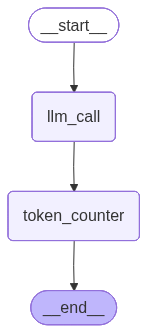

In [12]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
# Calling entire flow / Graph -> use invoke,astream

In [14]:
result = app.invoke({
    "messages" : [HumanMessage(content="Hi , This is Venkatesh,say hello in detail")]
})

In [15]:
result

{'messages': [HumanMessage(content='Hi , This is Venkatesh,say hello in detail', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Namaste! It's a pleasure to connect with you. My name is Venkatesh, and I'm excited to say hello to you. \n\nA warm and hearty 'Namaste' from my side, which is an ancient Indian greeting that conveys respect and a deep sense of connection. It's a way of acknowledging the divine in each other and expressing a desire to connect on a deeper level. \n\nHello, I hope this message finds you in the best of spirits and health. I'm Venkatesh, and I'm looking forward to our conversation. What brings you here today, and how can I be of assistance to you?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 132, 'prompt_tokens': 48, 'total_tokens': 180, 'completion_time': 0.316889, 'completion_tokens_details': None, 'prompt_time': 0.002287675, 'prompt_tokens_details': None, 'queue_time': 0.04687859, 'total_time': 0.319176675},

In [16]:
for M in result['messages']:
    print(type(M).__name__,":", M.content)

HumanMessage : Hi , This is Venkatesh,say hello in detail
AIMessage : Namaste! It's a pleasure to connect with you. My name is Venkatesh, and I'm excited to say hello to you. 

A warm and hearty 'Namaste' from my side, which is an ancient Indian greeting that conveys respect and a deep sense of connection. It's a way of acknowledging the divine in each other and expressing a desire to connect on a deeper level. 

Hello, I hope this message finds you in the best of spirits and health. I'm Venkatesh, and I'm looking forward to our conversation. What brings you here today, and how can I be of assistance to you?
AIMessage : Total token number in the generated answer (word count) is 100


In [17]:
result = app.invoke({
    "messages" : [HumanMessage(content="Good to hear you ! and Bye Now !")] 
})

In [18]:
for M in result['messages']:
    print(type(M).__name__,":", M.content)

HumanMessage : Good to hear you ! and Bye Now !
AIMessage : It was a brief interaction. Have a great day and feel free to reach out if you have any questions or need help in the future. Bye for now!
AIMessage : Total token number in the generated answer (word count) is 29


In [19]:
result

{'messages': [HumanMessage(content='Good to hear you ! and Bye Now !', additional_kwargs={}, response_metadata={}),
  AIMessage(content='It was a brief interaction. Have a great day and feel free to reach out if you have any questions or need help in the future. Bye for now!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 44, 'total_tokens': 77, 'completion_time': 0.053411946, 'completion_tokens_details': None, 'prompt_time': 0.003373139, 'prompt_tokens_details': None, 'queue_time': 0.047307437, 'total_time': 0.056785085}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c5b1c-79b5-7a30-8c39-cfcd6dc1c7e9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 33, 'total_tokens': 77}),
  AIMessage(content='Total token number in the generated answer (word co

- If you use [response], the old user message "Hello" is discarded — only the AI’s reply remains.
- If you want to keep the conversation history, you should append instead

return {
    "messages": state["messages"] + [response]
}


Tool Calling 

In [20]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [21]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max=500)

In [22]:
wiki_tool =WikipediaQueryRun(api_wrapper=api_wrapper)

In [23]:
wiki_tool.run({"query":"Transformers in Large language models"})

'Page: Large language model\nSummary: A large language model (LLM) is a language model trained with self-supervised machine learning on a vast amount of text, designed for natural language processing tasks, especially language generation. The largest and most capable LLMs are generative pre-trained transformers (GPTs) that provide the core capabilities of modern chatbots. LLMs can be fine-tuned for specific tasks or guided by prompt engineering. These models acquire predictive power regarding synt'

In [24]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults

In [26]:
tool = TavilySearchResults()
tool.invoke({"query":"How is the future of LLM?"})

C:\Users\Venkatesh\AppData\Local\Temp\ipykernel_12688\777615275.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults()


[{'title': 'LLM Trends 2025: A Deep Dive into the Future of Large Models',
  'url': 'https://prajnaaiwisdom.medium.com/llm-trends-2025-a-deep-dive-into-the-future-of-large-language-models-bff23aa7cdbc',
  'content': '1. The Evolution of LLMs: From Research Prototypes to Ubiquitous Tools\n\nLarge language models have come a long way since the early days of statistical language modeling. Today’s LLMs — powered by transformer architectures — have grown in size, capability, and complexity. They are no longer just academic curiosities; they are deployed across industries and are reshaping workflows in finance, healthcare, retail, manufacturing, and more. As noted on Wikipedia, LLMs are “designed for natural language processing tasks such as language generation” and have demonstrated impressive abilities in predicting syntax, semantics, and even generating creative content. [...] Venture capital investments are also surging. As LLMs continue to demonstrate their transformative potential, inv

In [27]:
from langchain_community.tools import DuckDuckGoSearchResults
search = DuckDuckGoSearchResults()

In [29]:
search.invoke("what's latest news on LLM?")

Impersonate 'chrome_126' does not exist, using 'random'


"snippet: 1 day ago · Your daily source for LLM news , open source LLM updates, and large language model news. Breaking announcements, new AI model releases, LLM benchmark news, and the latest updates from the AI industry., title: LLM News Today (February 2026) – Open Source LLM Updates & AI ..., link: https://llm-stats.com/ai-news, snippet: Jan 23, 2026 · In recent years, language models have become increasingly powerful and sophisticated. Get the latest information on LLM ' s here at AI Business. The model is part of a move toward regional and national development of AI technology., title: Language models recent news - AI Business, link: https://aibusiness.com/nlp/language-models, snippet: 3 days ago · A newsfeed of the latest news , updates and articles related to LLM ., title: LLM News, Updates and Articles, link: https://llm-explorer.com/static/llm-news/, snippet: Stay updated with the latest breakthroughs in Artificial Intelligence and Large Language Models. Explore research high

In [30]:
# BingSearch , googleserpai API

In [31]:
from langchain_community.tools import YouTubeSearchTool
youtube_tool = YouTubeSearchTool()

In [32]:
youtube_tool.name

'youtube_search'

In [33]:
youtube_tool.run("LLM")

"['https://www.youtube.com/watch?v=67_aMPDk2zw&pp=ygUDTExN', 'https://www.youtube.com/watch?v=5sLYAQS9sWQ&pp=ygUDTExN']"

In [36]:
# A Simple Method , can not call run or Invoke method
def multiply(a:int , b:int)-> int:
    return a *b

multiply(10,20)

200

In [37]:
# Use @tool decorator
from langchain.tools import tool

@tool
def multiply(y:int , z:int)->any:

    """Y : takes the integer input
       z : take the integer input
       return the multiplied value anytype"""
    
    return y*z

In [38]:
multiply.invoke({"y":50,"z":40})

2000

In [41]:
print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
Y : takes the integer input
       z : take the integer input
       return the multiplied value anytype
{'y': {'title': 'Y', 'type': 'integer'}, 'z': {'title': 'Z', 'type': 'integer'}}


In [42]:
@tool
def length_word(word:str)-> int:
    """it is a tool to count the length of the words"""
    return len(word)

In [43]:
length_word.invoke("hello large language models  and tool calling with Decorator")

60

In [44]:
length_word.args

{'word': {'title': 'Word', 'type': 'string'}}

In [45]:
import yfinance as yf

In [49]:
@tool
def get_Stock_price(ticker:str)-> str:

    """this is tool to get the stock price using yfinance"""
    try:

        stock = yf.Ticker(ticker) # ticker name of the stock

        # Get last 1 day historical data

        data = stock.history(period ="1d")

        if data.empty:
            return f"No data found for ticker {ticker} . please check the symbol"
        
        latest_close = data["Close"].iloc[-1]

        currency = stock.info.get("currency","")

        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£",
            "JPY": "¥",
            "CNY": "¥",
            "AUD": "A$",
            "CAD": "C$",
            "CHF": "CHF",
            "KRW": "₩",
            "RUB": "₽",
            "TRY": "₺",
            "BTC": "₿"
        }

        symbol =symbol_map.get(currency,"")
        currency_text = currency if currency else ""

        if symbol:
            return f"the last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}"
        else:
            return f"the last closing price of {ticker.upper()} was {latest_close:.2f}{currency_text}"


    except Exception as e:
        return f"An Error occured while fetching stock data : {str(e)}"

In [50]:
get_Stock_price.invoke("TCS.NS")

'the last closing price of TCS.NS was ₹2692.20'

In [51]:
get_Stock_price.invoke("CTS")

'the last closing price of CTS was $57.46'

In [53]:
get_Stock_price.invoke("AAPL")

'the last closing price of AAPL was $255.78'

In [60]:
get_Stock_price.invoke("TSLA")

'the last closing price of TSLA was $417.44'

In [62]:
get_Stock_price.invoke("HDFC")

$HDFC: possibly delisted; no price data found  (period=1d) (Yahoo error = "No data found, symbol may be delisted")


'No data found for ticker HDFC . please check the symbol'